# Stable DISCO under Randomness Sybils

This notebook analyzes `exp15_stable_disco_regression.csv` and compares naive residual magnitude with the stability-aware score under increasing Sybil output randomness.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [9]:
csv_path = os.path.join('..', 'results', 'tables', 'exp15_stable_disco_regression.csv')
df = pd.read_csv(csv_path)

print('Loaded:', csv_path)
print('Shape:', df.shape)
df.head()

Loaded: ../results/tables/exp15_stable_disco_regression.csv
Shape: (15, 12)


,trial,model_name,role,is_sybil,sybil_noise_std,naive_score,stable_magnitude,stability_variance,stable_score,max_weight,weight_entropy,mean_abs_residual
0,0,TreeModel_0,target,0,0.0,0.618243,0.333313,0.041885,0.128656,1.000019,8.289306e-11,0.333313
1,0,TreeModel_1,normal_peer,0,0.0,1.162884,0.273647,0.037248,0.080649,0.597571,6.739841e-01,0.273647
2,0,Sybil_noise_0.00,sybil,1,0.0,1.162884,0.273647,0.037248,0.080649,0.597571,6.739841e-01,0.273647
3,0,TreeModel_0,target,0,0.1,0.618243,0.333313,0.041885,0.128656,1.000019,8.289306e-11,0.333313
4,0,TreeModel_1,normal_peer,0,0.1,1.162884,0.273647,0.037248,0.080649,0.597571,6.739841e-01,0.273647


In [10]:
summary = (
    df.groupby(['role', 'sybil_noise_std'])[['naive_score', 'stable_score', 'stability_variance']]
      .mean()
      .reset_index()
)
summary

,role,sybil_noise_std,naive_score,stable_score,stability_variance
0,normal_peer,0.00,1.162884,0.080649,0.037248
1,normal_peer,0.10,1.162884,0.080649,0.037248
2,normal_peer,0.20,1.162884,0.080649,0.037248
3,normal_peer,0.35,1.162884,0.080649,0.037248
4,normal_peer,0.50,1.162884,0.080649,0.037248
5,sybil,0.00,1.162884,0.080649,0.037248
6,sybil,0.10,1.207535,0.065272,0.041823
7,sybil,0.20,1.260601,0.031648,0.060630
8,sybil,0.35,1.353773,-0.038528,0.115527
9,sybil,0.50,1.460425,-0.125092,0.202447


In [12]:
summary.drop(summary[summary['role'] == 'target'].index, inplace=True)

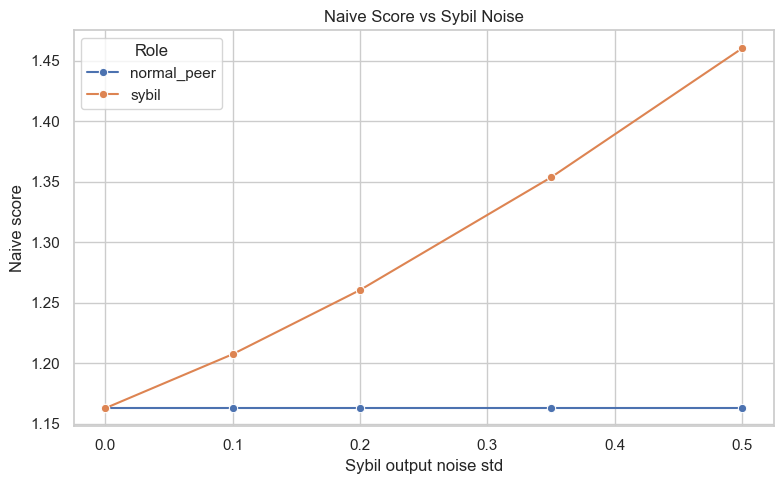

In [13]:
plt.figure()
sns.lineplot(data=summary, x='sybil_noise_std', y='naive_score', hue='role', marker='o')
plt.title('Naive Score vs Sybil Noise')
plt.xlabel('Sybil output noise std')
plt.ylabel('Naive score')
plt.legend(title='Role')
plt.tight_layout()
plt.show()
# we see here that the more noise the sybil the more its uniquness increases compared to the peer.

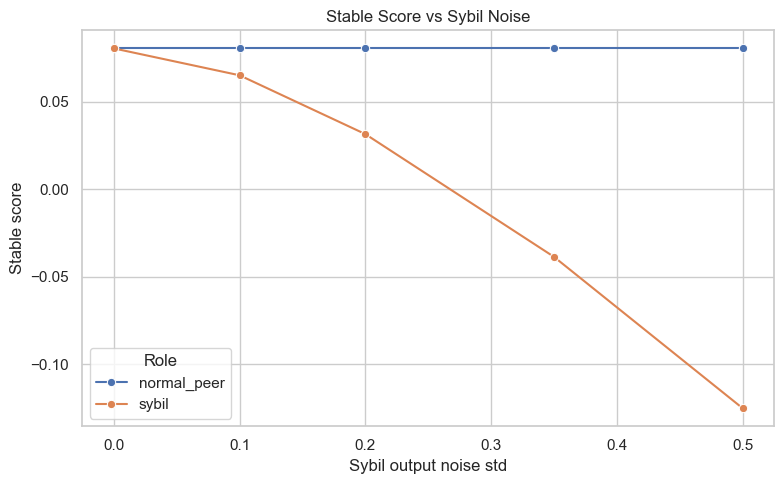

In [14]:
plt.figure()
sns.lineplot(data=summary, x='sybil_noise_std', y='stable_score', hue='role', marker='o')
plt.title('Stable Score vs Sybil Noise')
plt.xlabel('Sybil output noise std')
plt.ylabel('Stable score')
plt.legend(title='Role')
plt.tight_layout()
plt.show()

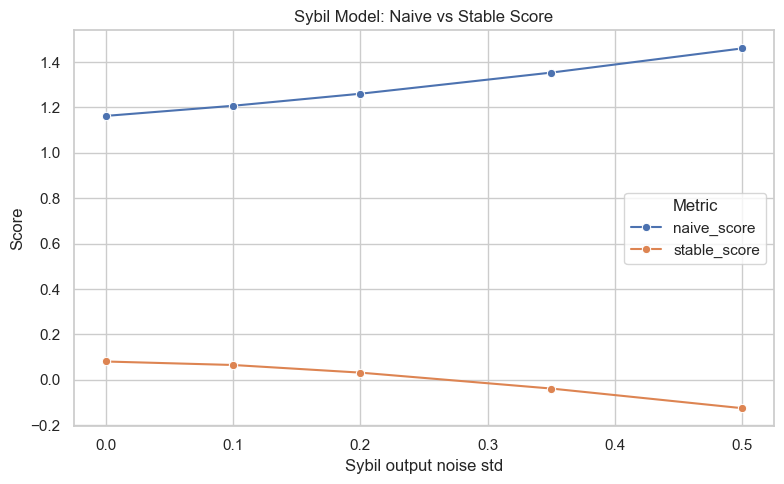

In [16]:
sybil_only = summary[summary['role'] == 'sybil'].copy()
melted = sybil_only.melt(
    id_vars=['sybil_noise_std'],
    value_vars=['naive_score', 'stable_score'],
    var_name='metric',
    value_name='score'
)

plt.figure()
sns.lineplot(data=melted, x='sybil_noise_std', y='score', hue='metric', marker='o')
plt.title('Sybil Model: Naive vs Stable Score')
plt.xlabel('Sybil output noise std')
plt.ylabel('Score')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
# but we can see that the stable score decreases. 

## Interpretation

If the stability-aware audit is working as intended, then as Sybil randomness increases:
- `naive_score` may stay high or increase (false novelty risk),
- `stability_variance` should rise, and
- `stable_score` should drop due to the variance penalty.

This directly operationalizes the proposal's Experiment 1 idea: residual magnitude alone can be fooled by stochastic Sybils, while a stability-aware score is more conservative.